# Project 3: Discrete logistic growth

MCSB Bootcamp — Mathematical and Computational Track

Jun Allard

## Model statement

Suppose a rabbit colony has a population $x(n)$ at month $n$, where $x$
is measured in thousands. If the population were growing in an unbounded
environment, the population obeys

$$x(n+1) = x(n) + r \cdot x(n)$$

where $r$ is the per-capita growth rate. Suppose instead the population
is in a bounded environment (like an island), so growth is limited and
the population obeys

$$x(n+1) = x(n) + r \left( 1 - \frac{x(n)}{K}\right) x(n)$$

where $K$ is a parameter we refer to as the carrying capacity.

## Part I

Suppose $r=0.1$ and $K=0.6$.

a.  According to your intuition, what population sizes are *steady
    states*, meaning that if the population had that value at time
    $n=0$, then it would remain at that value?

In [ ]:
# 0 and N=k

b.  Sketch your intuition for the population $x(t)$ from a starting
    population $x(1)=0.2$.

In [ ]:
# 

## Part II

Write code to solve the dynamical system, and answer the following
questions:

c.  Suppose $r=0.1$ and $K=0.6$. Generate time series of the populations
    for a few starting populations $x(1)$. Does it match your intuition?

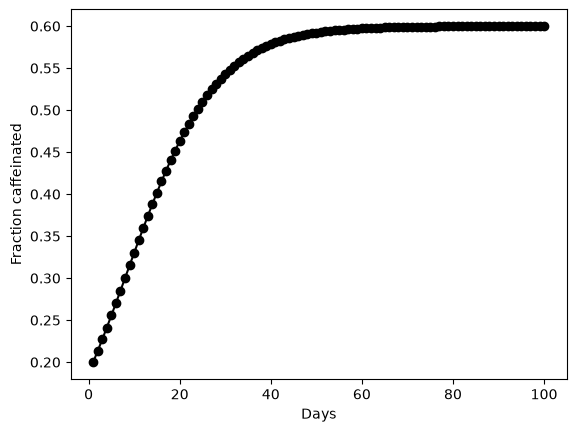

In [35]:
import numpy as np
import matplotlib.pyplot as plt

N = 10
n_maxd = 10*N

r=0.1
K=0.6
i = 0.2
def run_sim(rate,max_v,initial_v,n_max):
    x = np.zeros(n_max)  # fraction caffeinated
    x[0] = initial_v  # initial fraction caffeinated

    for n in range(1, n_max):

        x[n] = x[n - 1] + rate*(x[n-1])*(1-((x[n-1]/max_v)))

    # finished loop through days

    days = np.arange(1, n_max + 1)

    fig, ax = plt.subplots()
    ax.plot(days, x, "-ok")
    ax.set_ylabel("Fraction caffeinated")
    ax.set_xlabel("Days")
    plt.show()
    return
run_sim(r,K,i,n_maxd)

d.  Suppose $r=2.1$ and $K=0.6$. Generate time series of the populations
    for a few starting populations $x(1)$.

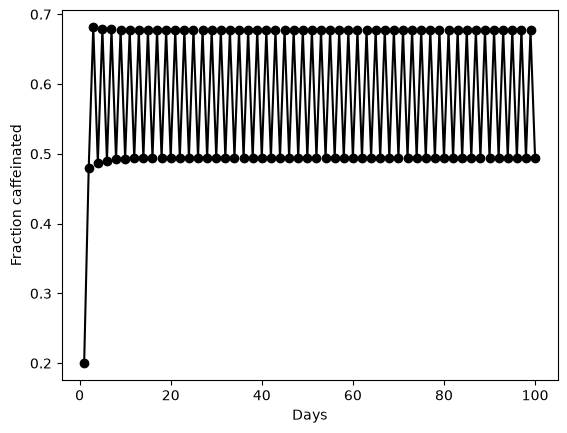

In [5]:

r=2.1
K=0.6
i= 0.2
run_sim(r,K,i)

## Part III

In a discrete-time dynamical system, if the population cycles between
two values, the solution is called a two-cycle. Cycling between $N$
values is called an $N$-cycle.

e.  Check that at $r=2.5$ and $K=0.6$ there is a 4-cycle.

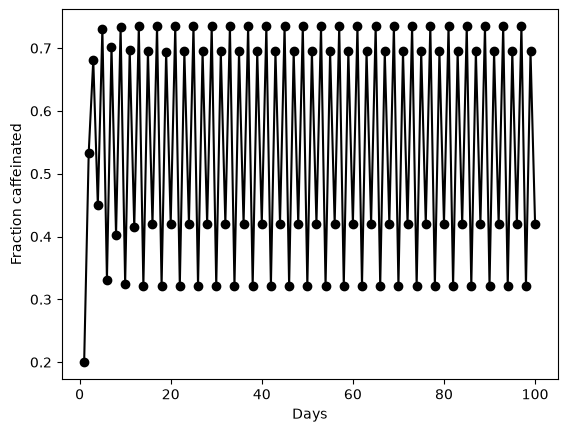

In [6]:
r=2.5
run_sim(r,K,i)

f.  (Optional) Can you find a value of $r$, $K$ and $x(1)$ that gives a
    3-cycle?

In [34]:
def run_sim_u(rate,max_v,initial_v,n_max):
    
    x = np.zeros(n_max)  # fraction caffeinated
    x[0] = initial_v  # initial fraction caffeinated

    for n in range(1, n_max):

        x[n] = x[n - 1] + rate*(x[n-1])*(1-((x[n-1]/max_v)))

    # finished loop through days

    days = np.arange(1, n_max + 1)

    unique =np.unique(np.round(x[80:],4))
    if len(unique)==3:
        print(f'Unique values ({len(unique)}): {unique}, r= {rate}')
    
    return

Unique values (3): [0.1268 0.4098 0.7774], r= 2.83


/var/folders/yd/gk03k1qj5mb73tyvj863828r0000gn/T/ipykernel_38097/4071668162.py:8: RuntimeWarning: overflow encountered in scalar multiply
  x[n] = x[n - 1] + rate*(x[n-1])*(1-((x[n-1]/max_v)))


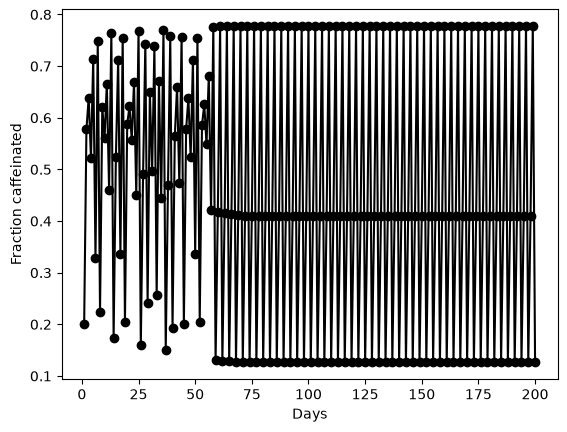

In [39]:
for v in range(0,1000,1):
    r = v/100 + 2.1

    run_sim_u(r,K,i,n_maxd)
r=2.83
run_sim(r,K,i,200)

g.  In this part, we will do a parameter sweep for $0<r<3.0$, with fixed
    $K=0.6$. The goal is to generate a diagram where the horizontal axis
    is the parameter value $r$. On the vertical axis, if there is a
    stable steady state, plot the steady-state population. If there is
    an $N$-cycle, plot the $N$ values of $x$ that it cycles through.

Hint: One way to plot the steady state or the $N$-cycle is to simulate
the system until $n_\mathrm{max}$, and plot the last half of the values
of $x(n)$. You need to choose $n_\mathrm{max}$ large enough so that the
dynamics have settled into their steady state (or steady cycle) by
$n_\mathrm{max}/2$.

Hint: How many $r$ values should you explore?

In [58]:
def run_sim_r(rate,max_v,initial_v,n_max):
    
    x = np.zeros(n_max)  # fraction caffeinated
    x[0] = initial_v  # initial fraction caffeinated

    for n in range(1, n_max):

        x[n] = x[n - 1] + rate*(x[n-1])*(1-((x[n-1]/max_v)))

    # finished loop through days

    days = np.arange(1, n_max + 1)

    unique =np.unique(np.round(x[100:],3))
    
    return unique

/var/folders/yd/gk03k1qj5mb73tyvj863828r0000gn/T/ipykernel_38097/791670595.py:8: RuntimeWarning: overflow encountered in scalar multiply
  x[n] = x[n - 1] + rate*(x[n-1])*(1-((x[n-1]/max_v)))
/var/folders/yd/gk03k1qj5mb73tyvj863828r0000gn/T/ipykernel_38097/791670595.py:8: RuntimeWarning: overflow encountered in scalar divide
  x[n] = x[n - 1] + rate*(x[n-1])*(1-((x[n-1]/max_v)))


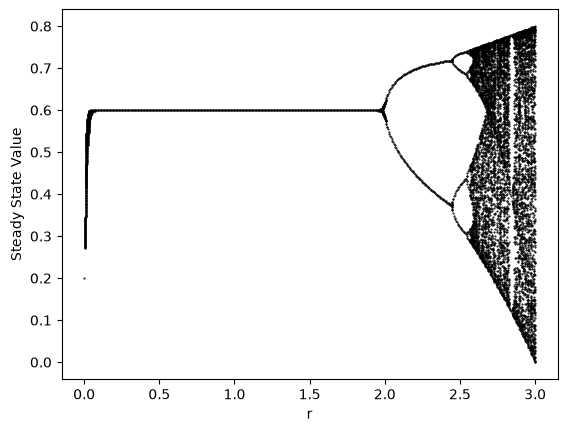

In [62]:
ss= {}
for v in range(0,6000,1):
    r = v/200 
    ss[r] = run_sim_r(r,K,i,200)
fig, ax = plt.subplots()
for rate in ss:
    ax.plot([rate]*len(ss[rate]), ss[rate], ".k", ms=1)
ax.set_ylabel("Steady State Value")
ax.set_xlabel("r")
plt.show()

This type of behavior in a dynamical system is called *chaos*! This
particular type of chaos is called period-doubling chaos.